
# Линейная регрессия. Практическая работа

## Цель практической работы

Научиться строить модель линейной регрессии на реальных данных.

## Что входит в практическую работу


1. Загрузить данные и ознакомиться с ними.
2. Изучить данные и провести анализ.
3. Разделить данные на обучающую и тестовую выборки.
4. Реализовать построение модели с помощью  библиотеки scikit-learn.
5. Получить качество модели с помощью MSE, MAE.


## Что оценивается 

* Выполнены все этапы работы.
* Сделан вывод по результатам.
* Модель не переобучена.
* Получена модель хорошего качества.

## Как отправить работу на проверку

Скачайте файл с заданиями в материалах, откройте его через Jupyter Notebook и выполните задачи. Сохраните изменения при помощи опции Save and Checkpoint из вкладки меню File или кнопки Save and Checkpoint на панели инструментов. Отправьте через форму ниже итоговый файл Jupyter Notebook (в формате .ipynb) или ссылку на него.



## Что нужно сделать

Пусть у нас имеется некоторый набор данных `sales.csv` о продажах квартир:

- **SalePrice** (цена продажи, *зависимая переменная*).
- **GrLivArea** (наземная жилая зона).
- **OverallQuality** (общее качество).
- **GarageArea** (территория гаража).
- **SaleCondition** (условия сделки).

Реализуйте построение модели линейной регрессии на этих данных. Проверьте качество модели на обучающей и тестовой выборках с помощью MAE, MSE. Определите, что вы не переобучились.

### 1. Импорт библиотек

In [1]:
# Ваш код здесь
import pandas as pd 

from sklearn.model_selection import train_test_split 
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

### 2. Загрузка данных

In [2]:
# Ваш код здесь
df = pd.read_csv('sales.csv')
df

,SalePrice,GrLivArea,GarageArea,OverallQual,Street,SaleCondition
0,208500,1710,548,7,Pave,Normal
1,181500,1262,460,6,Pave,Normal
2,223500,1786,608,7,Pave,Normal
3,140000,1717,642,7,Pave,Abnorml
4,250000,2198,836,8,Pave,Normal
...,...,...,...,...,...,...
1455,175000,1647,460,6,Pave,Normal
1456,210000,2073,500,6,Pave,Normal
1457,266500,2340,252,7,Pave,Normal
1458,142125,1078,240,5,Pave,Normal


### 3. Первичный анализ

1. Проведите анализ данных, посмотрите на индивидуальные графики зависимости целевой функции и отдельной переменной. Нередко, если признаков в выборке не так много, удобно построить [sns.pairplot](https://seaborn.pydata.org/generated/seaborn.pairplot.html).
2. Закодируйте категориальные признаки (например, с помощью [pd.get_dummies](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html)).
3. Подумайте, можно ли здесь создать дополнительные переменные из имеющихся.
4. Сделайте предварительные выводы.

C:\Users\Антон\AppData\Local\Temp\ipykernel_18272\2622616186.py:4: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  columns = df.corr().columns.tolist()
C:\Users\Антон\AppData\Local\Temp\ipykernel_18272\2622616186.py:5: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  plt.imshow(df.corr())


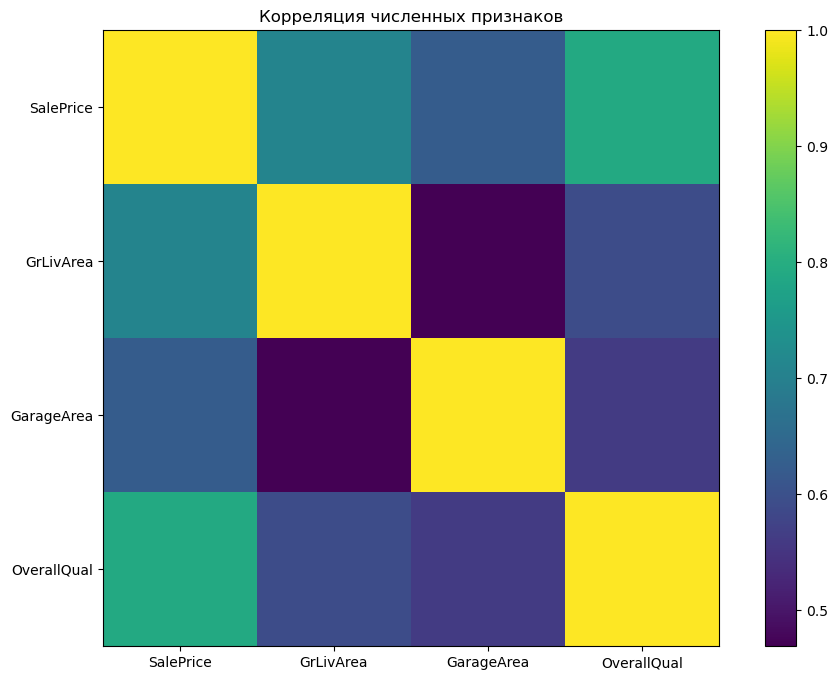

In [3]:
# Ваш код здесь
plt.figure(figsize=(12, 8))

columns = df.corr().columns.tolist()
plt.imshow(df.corr())

plt.title("Корреляция численных признаков")
plt.xticks(range(0, len(columns)), columns)
plt.yticks(range(0, len(columns)), columns)
plt.colorbar()
plt.show()

In [4]:
df_dum = pd.get_dummies(df, prefix=['Street', 'SaleCondition'])
df_dum

,SalePrice,GrLivArea,GarageArea,OverallQual,Street_Grvl,Street_Pave,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,208500,1710,548,7,0,1,0,0,0,0,1,0
1,181500,1262,460,6,0,1,0,0,0,0,1,0
2,223500,1786,608,7,0,1,0,0,0,0,1,0
3,140000,1717,642,7,0,1,1,0,0,0,0,0
4,250000,2198,836,8,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1455,175000,1647,460,6,0,1,0,0,0,0,1,0
1456,210000,2073,500,6,0,1,0,0,0,0,1,0
1457,266500,2340,252,7,0,1,0,0,0,0,1,0
1458,142125,1078,240,5,0,1,0,0,0,0,1,0


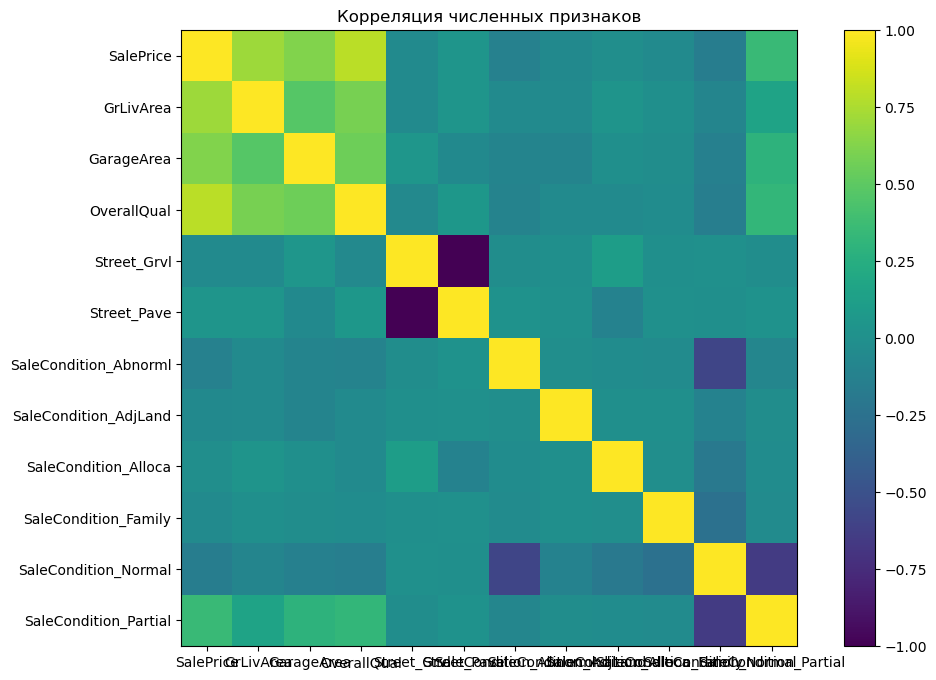

In [5]:
# Ваш код здесь
plt.figure(figsize=(12, 8))

columns = df_dum.corr().columns.tolist()
plt.imshow(df_dum.corr())

plt.title("Корреляция численных признаков")
plt.xticks(range(0, len(columns)), columns)
plt.yticks(range(0, len(columns)), columns)
plt.colorbar()
plt.show()

In [6]:
# Добавляем новый признак цена за кв.м.
def price_metr2(GrLivArea, GarageArea, sale):
    area = GrLivArea + GarageArea
    return sale/area

df_dum['price_m2'] = df_dum.apply(lambda x: price_metr2(x['GrLivArea'], x['GarageArea'], x['SalePrice']),axis=1)
df_dum['price_m2']

0        92.338353
1       105.400697
2        93.358396
3        59.347181
4        82.399473
           ...    
1455     83.056478
1456     81.616790
1457    102.816358
1458    107.833839
1459     96.279373
Name: price_m2, Length: 1460, dtype: float64

### 4. Разделение на обучающую и тестовую выборки

In [7]:
# Ваш код здесь
X = df_dum.drop(['SalePrice'], axis=1)
y = df_dum['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.7, random_state=63)

### 5. Обучение модели линейной регрессии

Дополнительно можно взглянуть на коэффициенты и смещение обученной модели.

In [8]:
# Ваш код здесь
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [9]:
#анализируем коэффициенты полученной модели.
print('w_0:', model.intercept_)
print('w_1:', model.coef_)

w_0: -207391.35920469405
w_1: [ 8.09916488e+01  9.44198933e+01  3.03189635e+03 -1.30335909e+04
  1.30335909e+04  7.12922882e+03  1.81898940e-12  6.43282077e+03
 -8.43484735e+02 -3.20491637e+03 -9.51364849e+03  2.09974558e+03]


### 6. Получение предсказаний для обучающей и тестовой выборок

In [11]:
# Ваш код здесь
y_predict_train = model.predict(X_train)

y_predict_test = model.predict(X_test)

### 7. Проверка предсказаний

1. Проверьте качество модели на обучающей и тестовой выборках с помощью MAE, MSE.
2. Постройте диаграмму рассеяния целевой и предсказанной переменных. 

In [12]:
# Ваш код здесь
train_mse = mean_squared_error(y_train, y_predict_train)
test_mse = mean_squared_error(y_test, y_predict_test)
print("Train MSE: {}".format(train_mse))
print("Test MSE: {}".format(test_mse))

Train MSE: 479531583.2975166
Test MSE: 363955151.83960414


In [13]:
train_mse = mean_absolute_error(y_train, y_predict_train)
test_mse = mean_absolute_error(y_test, y_predict_test)
print("Train MSE: {}".format(train_mse))
print("Test MSE: {}".format(test_mse))

Train MSE: 10441.73647757699
Test MSE: 10544.217436904273


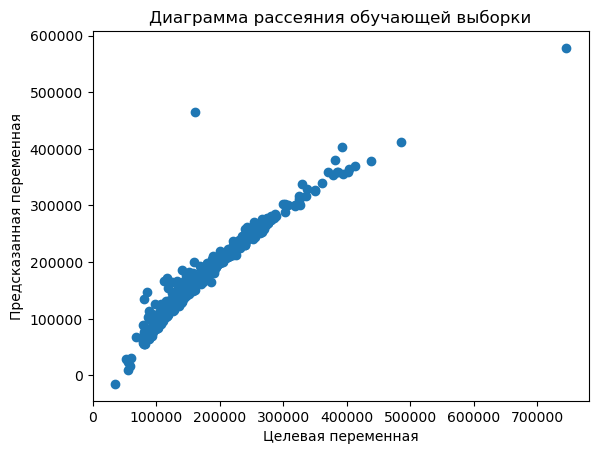

In [14]:
plt.scatter(y_train, y_predict_train)
plt.title("Диаграмма рассеяния обучающей выборки")
plt.xlabel("Целевая переменная")
plt.ylabel("Предсказанная переменная")

plt.show()

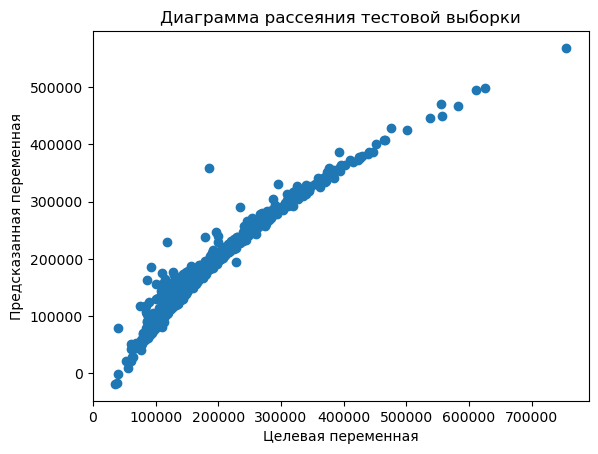

In [15]:
plt.scatter(y_test, y_predict_test)
plt.title("Диаграмма рассеяния тестовой выборки")
plt.xlabel("Целевая переменная")
plt.ylabel("Предсказанная переменная")

plt.show()